# Trend Scout — щоденний AI-дайджест у Telegram-канал (LangGraph)

**Фінальний проєкт** · курс Generative AI Developer (robot_dreams) · Роман Мицко · липень 2026

Репозиторій: https://github.com/RomanMytsko/trend-scout

**Ідея.** Щоденний моніторинг agentic-новин — рутина з чіткою декомпозицією: знайти → відібрати → написати → перевірити → опублікувати. Trend Scout автоматизує її мультиагентною системою за патерном **orchestrator–workers** і щодня постить результат у Telegram-канал (без налаштованого каналу — dry-run з превʼю поста):

```
planner ──> researcher ──> curator ──> writer ──> judge ──> publisher ──> archive ──> END
   ^            │                        ^          │
   └── replan ──┘ (мало матеріалу)       └─ revise ─┘ (оцінка < 4.0)
```

| Вузол | Тип | Відповідальність |
|---|---|---|
| planner | LLM-агент | декомпозиція тем у пошукові запити (structured output) |
| researcher | tool-воркер | RSS + DDG news; дедуплікація за URL і семантична (embeddings), фільтр памʼяті |
| curator | LLM-агент | ранжування/фільтрація під аудиторію, відсів маркетингу |
| writer | LLM-агент | дайджест у строгому форматі; враховує фідбек judge |
| judge | guardrail + LLM-as-a-judge | URL-allowlist перевірка + рубрика 1–5 за 3 критеріями |
| publisher | tool-воркер | рендерить Telegram-HTML і постить у канал (без каналу — dry-run) |
| archive | памʼять | зберігає доставлені сюжети в Chroma, щоб прогони не повторювались |

Дві петлі зворотного звʼязку (replan і revise) обмежені лічильниками — гарантія завершення.

In [1]:
%pip install -q git+https://github.com/RomanMytsko/trend-scout.git

Note: you may need to restart the kernel to use updated packages.


## API-ключ

Потрібен лише `OPENAI_API_KEY` (пошук і RSS — безключові). У Colab додай ключ у **Secrets** (іконка 🔑 зліва) або введи нижче.

In [2]:
import os

if not os.environ.get("OPENAI_API_KEY"):
    try:
        from google.colab import userdata
        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    except Exception:
        import getpass
        os.environ["OPENAI_API_KEY"] = getpass.getpass("OPENAI_API_KEY: ")

# Мова дайджесту і аудиторія конфігуруються через env (див. .env.example)
os.environ.setdefault("DIGEST_LANGUAGE", "Ukrainian")
os.environ.setdefault("AUDIENCE", "backend Python engineer")
print("OK")

OK


## Візуалізація графа

LangGraph компілює `StateGraph` з умовними переходами — подивимось на нього.

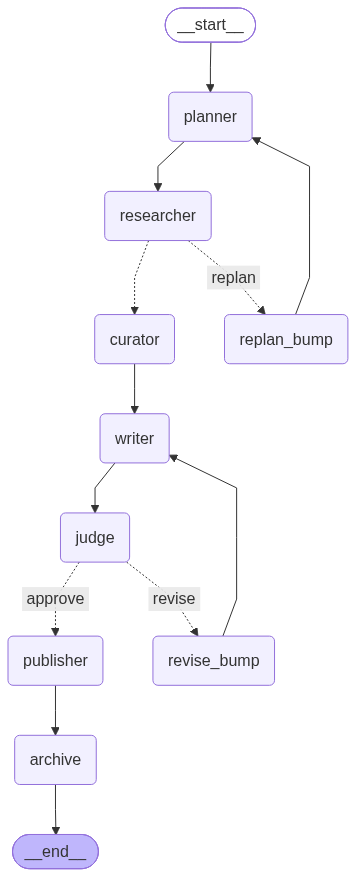

In [3]:
from trend_scout import graph

app = graph.build_graph()

try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())  # fallback: mermaid-текст

## Запуск пайплайну

Теми можна міняти на свої. Виконання ~1–3 хв: RSS-фіди, кілька пошукових запитів і 4–6 LLM-викликів.

In [4]:
TOPICS = [
    "multi-agent orchestration",
    "MCP and A2A protocols",
    "LangGraph and agent frameworks",
    "context engineering",
]

state = graph.run_digest(TOPICS)

print("--- pipeline events ---")
for event in state["events"]:
    print(" ", event)

Web search failed for query 'multi-agent orchestration frameworks Python 2024'
Traceback (most recent call last):
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/trend_scout/tools.py", line 68, in web_search
    ddgs.news(query, max_results=max_results, timelimit=settings.search_timelimit)
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 466, in news
    return self._search_sync("news", query, **kwargs)
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 454, in _search_sync
    raise DDGSException(err or "No results found.")
ddgs.exceptions.DDGSException: No results found.


Web search failed for query 'latest MCP protocol updates backend systems'
Traceback (most recent call last):
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/trend_scout/tools.py", line 68, in web_search
    ddgs.news(query, max_results=max_results, timelimit=settings.search_timelimit)
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 466, in news
    return self._search_sync("news", query, **kwargs)
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 454, in _search_sync
    raise DDGSException(err or "No results found.")
ddgs.exceptions.DDGSException: No results found.


Web search failed for query 'A2A communication protocols in distributed agents'
Traceback (most recent call last):
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/trend_scout/tools.py", line 68, in web_search
    ddgs.news(query, max_results=max_results, timelimit=settings.search_timelimit)
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 466, in news
    return self._search_sync("news", query, **kwargs)
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 454, in _search_sync
    raise DDGSException(err or "No results found.")
ddgs.exceptions.DDGSException: No results found.


Web search failed for query 'LangGraph agent framework Python examples'
Traceback (most recent call last):
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/trend_scout/tools.py", line 68, in web_search
    ddgs.news(query, max_results=max_results, timelimit=settings.search_timelimit)
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 466, in news
    return self._search_sync("news", query, **kwargs)
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 454, in _search_sync
    raise DDGSException(err or "No results found.")
ddgs.exceptions.DDGSException: No results found.


Web search failed for query 'multi-agent orchestration best practices 2024 backend development'
Traceback (most recent call last):
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/trend_scout/tools.py", line 68, in web_search
    ddgs.news(query, max_results=max_results, timelimit=settings.search_timelimit)
    ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 466, in news
    return self._search_sync("news", query, **kwargs)
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 454, in _search_sync
    raise DDGSException(err or "No results found.")
ddgs.exceptions.DDGSException: No results found.


--- pipeline events ---
  planner: 6 queries
  researcher: 20 rss + search -> 21 unique items
  curator: picked 5 items
  writer: draft #0 ready
  judge: relevance=4 grounding=5 format=3 avg=4.00
  publisher: dry-run (channel not configured), post saved to telegram_post_preview.html
  archive: remembered 5 delivered stories


## Оцінка якості (LLM-as-a-judge)

Перед рубрикою LLM-судді спрацьовує **детермінований guardrail**: усі лінки в дайджесті мають входити до allowlist зібраних URL (захист від галюцинованих джерел і prompt injection у сніпетах).

In [5]:
verdict = state["verdict"]
print(f"relevance    : {verdict.relevance}/5")
print(f"grounding    : {verdict.grounding}/5")
print(f"format       : {verdict.format_score}/5")
print(f"average      : {verdict.average:.2f} (поріг 4.0)")
print(f"ревізій      : {state.get('revisions', 0)}")
print(f"replan-ів    : {state.get('replans', 0)}")
print(f"\nфідбек судді: {verdict.feedback}")

relevance    : 4/5
grounding    : 5/5
format       : 3/5
average      : 4.00 (поріг 4.0)
ревізій      : 0
replan-ів    : 0

фідбек судді: The digest is generally relevant to the topics of multi-agent orchestration, AI model context engineering, and backend Python engineering, with a good selection of items. However, the connection to MCP and A2A protocols, LangGraph, and explicit agent frameworks could be made more explicit to better match the audience's interests. Grounding is strong; all claims are supported by the source titles and snippets, and URLs are correct. The format mostly follows the required Ukrainian structure with title, intro, and per-item sections with 'Суть', 'Чому важливо', and 'Лінк'. However, the main title and intro are in Ukrainian but the item titles remain in English, which is inconsistent with the requirement for exact Ukrainian structure. Also, the intro could be expanded slightly to better set the context for the backend Python engineer audience. To improve,

## Результат — дайджест

In [6]:
from IPython.display import Markdown, display

display(Markdown(state["digest"]))

# Огляд новин для backend Python інженерів: AI, контекст та продуктивність

Цей дайджест охоплює ключові оновлення у сфері AI моделей, оптимізації контексту, продуктивності середовищ виконання та безпеки.

## 1. I burned all my tokens researching how to save tokens  
- Суть: Стаття описує створення кастомного deep research pipeline для економії токенів. Розглядаються методи оптимізації використання токенів у багатозадачних агентських системах.  
- Чому важливо: Ефективне управління токенами критично для зниження витрат і підвищення продуктивності backend систем, що працюють з AI.  
- Лінк: [quesma.com/blog/custom-deep-research-pipeline](https://quesma.com/blog/custom-deep-research-pipeline/)

## 2. Claude Code uses Bun written in Rust now  
- Суть: Проєкт Claude Code перейшов на використання Bun, середовища виконання, написаного на Rust. Це демонструє покращення продуктивності та інструментів для бекенд-розробки.  
- Чому важливо: Знання про ефективні runtime середовища допоможе оптимізувати backend Python сервіси, особливо при роботі з агентськими фреймворками.  
- Лінк: [simonwillison.net/2026/Jul/19/claude-code-in-bun-in-rust](https://simonwillison.net/2026/Jul/19/claude-code-in-bun-in-rust/)

## 3. OpenAI reduces Codex Model Context Size from 372k to 272k  
- Суть: OpenAI зменшила розмір контексту моделі Codex з 372 тисяч до 272 тисяч токенів. Це важливе оновлення протоколу і моделі для роботи з великими контекстами.  
- Чому важливо: Зміни в розмірі контексту впливають на архітектуру backend систем, що інтегрують AI, і вимагають адаптації контекстної інженерії.  
- Лінк: [github.com/openai/codex/pull/33972/files](https://github.com/openai/codex/pull/33972/files)

## 4. Transcribe.cpp  
- Суть: Transcribe.cpp — це open-source проєкт з великою спільнотою, що фокусується на транскрипції аудіо з використанням AI моделей.  
- Чому важливо: Цей проєкт цікавий для бекенд інженерів, які працюють з інтеграцією AI моделей і агентськими фреймворками.  
- Лінк: [workshop.cjpais.com/projects/transcribe-cpp](https://workshop.cjpais.com/projects/transcribe-cpp)

## 5. Open-weight AI models now match frontier cyber skill from four months prior, AISI finds  
- Суть: Звіт AI Security Institute показує, що відкриті AI моделі тепер досягають рівня кіберзахисту, який був актуальним чотири місяці тому.  
- Чому важливо: Розуміння поточних можливостей AI у кібербезпеці допоможе розробникам краще проектувати безпечні багатозадачні агентські системи.  
- Лінк: [msn.com/en-us/technology/artificial-intelligence/open-weight-ai-models-now-match-frontier-cyber-skill-from-four-months-prior-aisi-finds/ar-AA28fage](https://www.msn.com/en-us/technology/artificial-intelligence/open-weight-ai-models-now-match-frontier-cyber-skill-from-four-months-prior-aisi-finds/ar-AA28fage?ocid=BingNewsVerp)

## Зазирнемо всередину: проміжні стани агентів

In [7]:
print("PLAN (planner, structured output):")
print("  reasoning:", state["plan"].reasoning)
for q in state["plan"].queries:
    print("  query:", q)

print(f"\nITEMS (researcher): {len(state['items'])} зібрано, приклади:")
for item in state["items"][:5]:
    print(f"  [{item.source}] {item.title[:80]}")

print("\nCURATION (curator):")
for pick in state["curation"].picks:
    print(f"  #{pick.index} relevance={pick.relevance}: {pick.why_it_matters[:100]}")

PLAN (planner, structured output):
  reasoning: To cover the topics comprehensively for a backend Python engineer, the queries focus on recent developments and practical implementations in multi-agent orchestration, MCP and A2A protocols, LangGraph and agent frameworks, and context engineering. The queries are designed to find technical articles, tutorials, and recent research from the last week without broadening beyond the specified topics, ensuring relevance and depth.
  query: multi-agent orchestration frameworks Python 2024
  query: latest MCP protocol updates backend systems
  query: A2A communication protocols in distributed agents
  query: LangGraph agent framework Python examples
  query: context engineering techniques for AI agents
  query: multi-agent orchestration best practices 2024 backend development

ITEMS (researcher): 21 зібрано, приклади:
  [Hacker News (front page)] Clever hacker fits 537,000 domains in a $5 ESP32 ad-blocking dongle
  [Hacker News (front page)] DRIV

## Пост у Telegram

`publisher` конвертує дайджест у Telegram-HTML і надсилає в канал через Bot API. Тут канал не сконфігурований, тому вузол відпрацював у **dry-run**: готовий пост збережено локально — щоб публікувати по-справжньому, достатньо додати `TELEGRAM_BOT_TOKEN` і `TELEGRAM_CHANNEL_ID` у env, код не змінюється.

In [8]:
print(state["post"][:800])

<b>Огляд новин для backend Python інженерів: AI, контекст та продуктивність</b>

Цей дайджест охоплює ключові оновлення у сфері AI моделей, оптимізації контексту, продуктивності середовищ виконання та безпеки.

<b>1. I burned all my tokens researching how to save tokens</b>
• Суть: Стаття описує створення кастомного deep research pipeline для економії токенів. Розглядаються методи оптимізації використання токенів у багатозадачних агентських системах.  
• Чому важливо: Ефективне управління токенами критично для зниження витрат і підвищення продуктивності backend систем, що працюють з AI.  
• Лінк: <a href="https://quesma.com/blog/custom-deep-research-pipeline/">quesma.com/blog/custom-deep-research-pipeline</a>

<b>2. Claude Code uses Bun written in Rust now</b>
• Суть: Проєкт Claude Code пе


## Семантична дедуплікація і памʼять між прогонами

Два застосування embeddings (`text-embedding-3-small`):

- **Semantic dedupe** — той самий сюжет, передрукований різними виданнями, схлопується до одного айтема (greedy cosine clustering, поріг 0.86). URL-дедуплікація такого не ловить.
- **Cross-run memory** — після апруву судді вузол `archive` зберігає доставлені сюжети в ChromaDB; наступний прогін відкидає семантично близькі кандидати (поріг 0.88), тож тижневі дайджести не повторюються.

У подіях вище це видно як `semantic: dedupe N -> M` і `memory: dropped K already-covered`. Запусти пайплайн двічі — другий прогін відфільтрує вже доставлені сюжети (памʼять у Colab живе в межах сесії, локально — у `.trend_scout_memory/`).

## Висновки

- **Патерн orchestrator–workers** реалізований на LangGraph: LLM-агенти планують/курують/пишуть, детермінований воркер виконує інструменти.
- **Structured outputs (Pydantic)** у кожного агента — жодного парсингу вільного тексту.
- **LLM-as-a-judge** як quality gate з петлею ревізій і порогом 4.0.
- **Embeddings у двох ролях**: семантична дедуплікація сюжетів і Chroma-памʼять доставленого між прогонами.
- **Guardrails проти prompt injection**: санітизація контенту, явне маркування untrusted-даних у промптах, детермінований URL-allowlist.
- **Надійність** як у бекенд-системах: graceful degradation інструментів, capped retries, event log.

Можливий розвиток: реальний канал — це два env-параметри; розклад — один рядок cron / Celery beat; далі A2A-інтерфейс і суддя на іншій моделі.